In [1]:
pip install pandas matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.7 MB 371.1 kB/s eta 0:00:25
   -- ------------------------------------- 0.5/9.7 MB 371.1 kB/s eta 0:00:25
   --- ------------------------------------ 0.8/9.7 MB 441.3 kB/s eta 0:00:21
   --- ------------------------------------ 0.8/9.7 MB 441.3 kB/s eta 0:00:21
   ---- ----------------------------------- 1.0/9.7 MB 532.0 kB/s eta 0:00:17
   ----- ---------------------------------- 1.3/9.7 MB 600.5 k

In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/transactions.csv")

df.head()

,Date,Description,Category,Amount,Payment_Mode,Location
0,2025-10-22,Movie,Entertainment,509.45,Credit Card,New Sandrafort
1,2025-06-19,Netflix,Entertainment,4526.73,Debit Card,North Brianport
2,2026-02-06,Uber,Travel,347.08,Cash,Blankenshipburgh
3,2025-06-28,Spotify,Entertainment,1278.02,Cash,Lake Donald
4,2025-10-30,Swiggy,Food,2496.97,Cash,Savannahburgh


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          5000 non-null   str    
 1   Description   5000 non-null   str    
 2   Category      5000 non-null   str    
 3   Amount        5000 non-null   float64
 4   Payment_Mode  5000 non-null   str    
 5   Location      5000 non-null   str    
dtypes: float64(1), str(5)
memory usage: 234.5 KB


In [5]:
df.describe()

,Amount
count,5000.000000
mean,2496.768790
std,1429.476843
min,50.390000
25%,1258.342500
50%,2486.670000
75%,3718.290000
max,4999.150000


In [6]:
df.isnull().sum()

Date            0
Description     0
Category        0
Amount          0
Payment_Mode    0
Location        0
dtype: int64

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df['Month'] = df['Date'].dt.month
df['Day_of_Week'] = df['Date'].dt.day_name()

In [9]:
total_spending = df['Amount'].sum()
print("Total Spending:", total_spending)

Total Spending: 12483843.95


In [10]:
category_spending = df.groupby('Category')['Amount'].sum()

print(category_spending)

Category
Bills            2449034.09
Entertainment    2481659.12
Food             2547117.00
Shopping         2464749.78
Travel           2541283.96
Name: Amount, dtype: float64


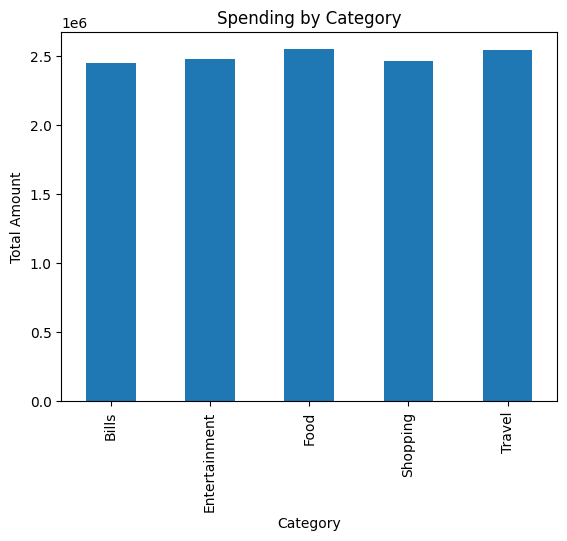

In [11]:
import matplotlib.pyplot as plt

category_spending.plot(kind='bar')

plt.title("Spending by Category")
plt.xlabel("Category")
plt.ylabel("Total Amount")

plt.show()

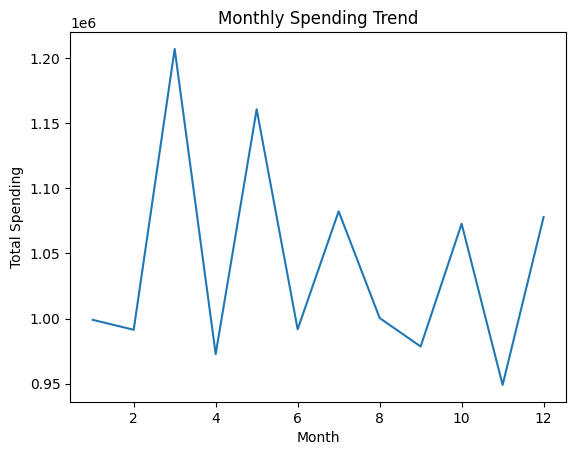

In [12]:
monthly_spending = df.groupby('Month')['Amount'].sum()

monthly_spending.plot()

plt.title("Monthly Spending Trend")
plt.xlabel("Month")
plt.ylabel("Total Spending")

plt.show()

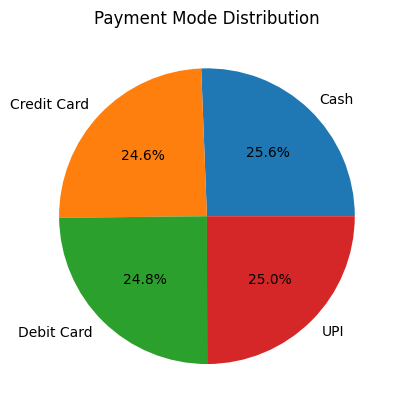

In [13]:
payment_spending = df.groupby('Payment_Mode')['Amount'].sum()

payment_spending.plot(kind='pie', autopct='%1.1f%%')

plt.title("Payment Mode Distribution")

plt.show()

In [15]:
df.to_csv("../data/processed/cleaned_transactions.csv", index=False)

In [16]:
import pandas as pd

df = pd.read_csv("../data/processed/cleaned_transactions.csv")

df.head()

,Date,Description,Category,Amount,Payment_Mode,Location,Month,Day_of_Week
0,2025-10-22,Movie,Entertainment,509.45,Credit Card,New Sandrafort,10,Wednesday
1,2025-06-19,Netflix,Entertainment,4526.73,Debit Card,North Brianport,6,Thursday
2,2026-02-06,Uber,Travel,347.08,Cash,Blankenshipburgh,2,Friday
3,2025-06-28,Spotify,Entertainment,1278.02,Cash,Lake Donald,6,Saturday
4,2025-10-30,Swiggy,Food,2496.97,Cash,Savannahburgh,10,Thursday


In [17]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.to_period('M')

monthly_spending = df.groupby('Month')['Amount'].sum().reset_index()

monthly_spending.head()

,Month,Amount
0,2025-03,895113.79
1,2025-04,972761.96
2,2025-05,1160612.09
3,2025-06,991781.02
4,2025-07,1082333.08


In [18]:
monthly_spending['Month'] = monthly_spending['Month'].astype(str)

monthly_spending['Month_Number'] = range(len(monthly_spending))

In [19]:
X = monthly_spending[['Month_Number']]
y = monthly_spending['Amount']

In [20]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 367.2 kB/s eta 0:00:21
   -- ------------------------------------- 0.5/8.0 MB 367.2 kB/s eta 0:00:21
   -- ------------------------------------- 0.5/8.0 MB 367.2 kB/s eta 0:00:21
   --- ------------------------------------ 0.8/8.0 MB 391.6 kB/s eta 0:00:19
   --- ------------------------------------ 0.8/8.0 MB 391.6 kB/s eta 0:00:19
   --- ------------------------------------ 0.8/8.0 MB 391.6 kB/s eta 0:00:19
   ----- ---------------------------------- 1.0/8.0 MB 425.1 kB/s eta 0:00:17
   ------ ------------------------------

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
next_month = [[len(monthly_spending)]]

prediction = model.predict(next_month)

print("Predicted spending for next month:", prediction[0])

Predicted spending for next month: 806904.421923077


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


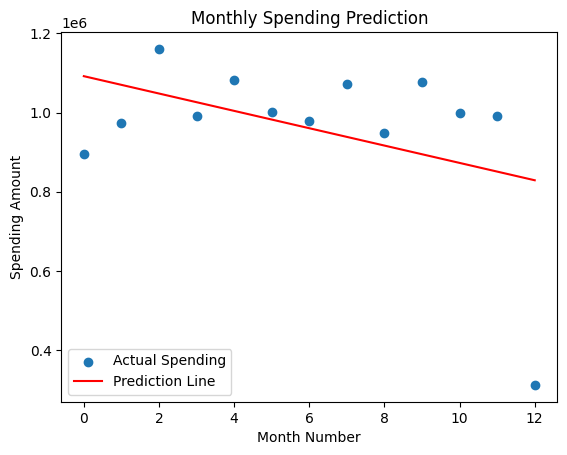

In [23]:
import matplotlib.pyplot as plt

plt.scatter(X, y, label="Actual Spending")

plt.plot(X, model.predict(X), color='red', label="Prediction Line")

plt.xlabel("Month Number")
plt.ylabel("Spending Amount")

plt.title("Monthly Spending Prediction")

plt.legend()

plt.show()

In [25]:
import pickle

with open("../models/spending_model.pkl", "wb") as f:
    pickle.dump(model, f)

SyntaxError: invalid character '—' (U+2014) (1334658425.py, line 1)